<h1>AI4I 2020 Predictive Maintenance — End-to-End Machine Learning</h1>

<h4>Objective</h4>

The aim of this project is to develop and compare machine-learning models for predicting machine failures using the AI4I 2020 Predictive Maintenance Dataset from the UCI Machine Learning Repository.

The workflow covers:
<ul>
<li>Exploratory Data Analysis (EDA)</li>
<li>Data preprocessing</li>
<li>Train/test splitting</li>
<li>Feature engineering</li>
<li>Machine-learning pipelines</li>
<li>Comparison of three classification models</li>
<li>Cross-validation</li>
<li>Evaluation using multiple classification metrics</li>
<li>Final model selection and interpretation</li>

</ul>

The target variable is whether a machine failure occurs (Machine failure).

**<h4>Import the libraries</h4>**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, OneHotEncoder)

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


**<h4>Get the dataset</h4>**

In [ ]:
df = pd.read_csv("ai4i2020.csv")

df.head() #Displays the first 5 rows of the dataset so you can quickly inspect the columns and see what the raw data looks like.

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.shape #Returns a tuple showing the dimensions of the dataset, representing the total number of (rows, columns)

(10000, 14)

In [ ]:
df.info() #Prints a summary of the DataFrame, including the data types of each column, the count of non-null (valid) values, and memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df.describe(include="all").T #• Generates descriptive statistics for both numeric and text columns (like mean, min, max, unique values, and frequencies), and the .T transposes the output table (swaps rows and columns) to make it easier to read vertically.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,M24859,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


**<h4>Initial data inspection</h4>**

In [ ]:
df.isnull().sum() #Now check missing values

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [10]:
df.duplicated().sum() # check for duplicate rows in the dataset. The .duplicated() method returns a boolean Series indicating whether each row is a duplicate of a previous row, and the .sum() method counts the number of True values, which represents the total number of duplicate rows in the DataFrame.

np.int64(0)

In [11]:
df.columns.tolist() #Check the column names in the dataset. The .columns attribute returns an Index object containing the column labels, and the .tolist() method converts this Index object into a regular Python list for easier viewing and manipulation.

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

**<h4>Import: understand the target</h4>**

In [13]:
target = "Machine failure"
df[target].value_counts() #Check the distribution of the target variable. The .value_counts() method counts the occurrences of each unique value in the specified column, providing insight into the balance of classes in the target variable.
df[target].value_counts(normalize=True) #Check the distribution of the target variable. The .value_counts() method counts the occurrences of each unique value in the specified column, providing insight into the balance of classes in the target variable. The normalize=True parameter returns the relative frequencies (proportions) instead of absolute counts, allowing for a better understanding of class distribution.

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

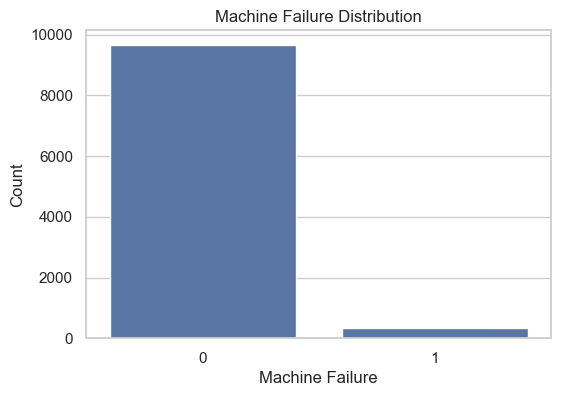

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

We see that:
<ul>
<li>most observations correspond to no machine failure</li>
<li>relatively few correspond to failure</li>
</ul>

This means the target is **imbalanced**.

That's important because a model could obtain deceptively high accuracy by mostly predicting "no failure."

<h3>Remove columns that shouldn't be used</h3>

Before modelling, we need to think carefully about the columns.

UDI is essentially an identifier.

Product ID is also an identifier.

So we generally don't want to feed those directly into the model.

In [16]:
df_model = df.drop(columns=["UDI", "Product ID"])
df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


<h3>One important modelling issue</h3>

The AI4I dataset contains:

TWF
HDF
PWF
OSF
RNF

These are failure-mode indicators.

For a realistic early predictive-maintenance model, using these variables requires caution because they are closely tied to the failure label and may represent information that is only available when/after a failure condition has been detected.

So I recommend that our main model use the machine's operational measurements:

Type
Air temperature [K]
Process temperature [K]
Rotational speed [rpm]
Torque [Nm]
Tool wear [min]

and predict:

**Machine failure**

This makes the problem much more meaningful from a predictive-maintenance perspective.

We can optionally discuss the failure-mode variables later as a data leakage / deployment consideration.

#### Define X and y

In [18]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[features]
y = df["Machine failure"]

X.head()
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

#### Train/test split

Because our target is imbalanced, use stratification.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
#Check the proportions of the target variable in the training and testing sets to ensure that they are similar to the original dataset's distribution. This is important for maintaining the representativeness of the data and avoiding bias in model evaluation.
print("Training set:")
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts(normalize=True))

Training set:
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Test set:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


#### Identify feature types

We have one categorical variable:

**Type**

and several numerical variables.

Define:

In [21]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

#### Build the preprocessing pipeline

This is an important part of the project because we don't want to preprocess the entire dataset before cross-validation.

We'll let the pipeline perform preprocessing **inside each training fold.**

In [22]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
# Then we combine them

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# This gives us a reusable preprocessing stage.

#### Define the 3 models

Model 1 — Logistic Regression

A simple interpretable baseline.

In [24]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

Model 2 — Random Forest

A nonlinear ensemble method:

In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced" # This tells the model to give more importance to the minority class.
)

Model 3 — Gradient Boosting

In [26]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

#### Put preprocessing + model into pipelines

In [27]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", logistic_model)
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", random_forest_model)
        ]
    ),

    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", gradient_boosting_model)
        ]
    )
}

#### Cross-validation

In [28]:
# We'll use Stratified 5-Fold Cross-Validation.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Our metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

Now evaluate all three models:

In [29]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Gradient Boosting,0.983000,0.861417,0.597912,0.703937,0.972782
1,Random Forest,0.977375,0.888730,0.380269,0.531236,0.967204
0,Logistic Regression,0.970375,0.760736,0.199327,0.311873,0.893808


#### Visualise model comparison

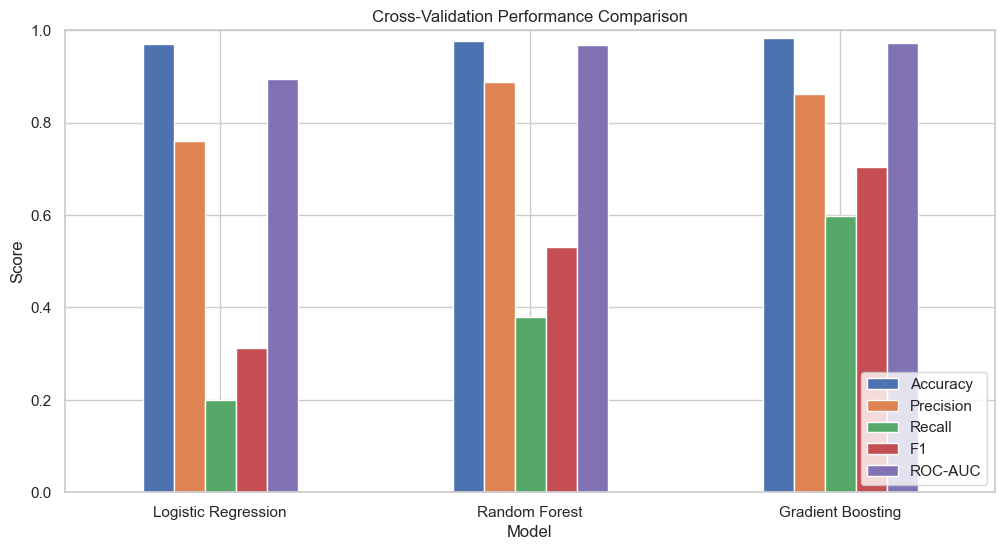

In [30]:
cv_results_plot = cv_results_df.set_index("Model")

cv_results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cross-Validation Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

#### Train the models

In [31]:
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

#### Evaluate on the test set

In [32]:
test_results = []

for name, model in fitted_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Gradient Boosting,0.9850,0.895833,0.632353,0.741379,0.965941
1,Random Forest,0.9800,0.911765,0.455882,0.607843,0.963357
0,Logistic Regression,0.9675,0.636364,0.102941,0.177215,0.899388


#### Classification report

In [33]:
for name, model in fitted_models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Failure", "Failure"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000

Random Forest
              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1932
     Failure       0.91      0.46      0.61        68

    accuracy                           0.98      2000
   macro avg       0.95      0.73      0.80      2000
weighted avg       0.98      0.98      0.98      2000

Gradient Boosting
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.90      0.63      0.74        68

    accuracy                           0.98      2000
   macro avg       0.94      0.81      0.87      2000
weighted avg       0.9

#### Confusion Matrix

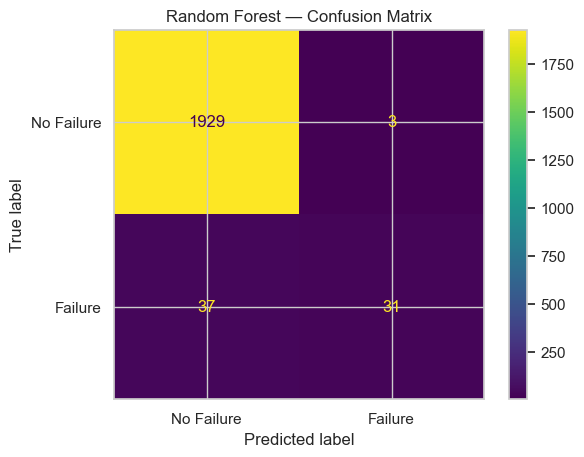

In [34]:
best_model = fitted_models["Random Forest"]

y_pred = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Failure", "Failure"]
)

plt.title("Random Forest — Confusion Matrix")
plt.show()

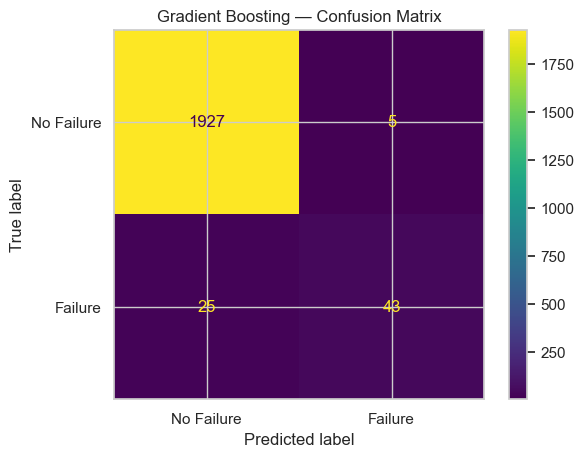

In [35]:
best_model_2 = fitted_models["Gradient Boosting"]

y_pred = best_model_2.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Failure", "Failure"]
)

plt.title("Gradient Boosting — Confusion Matrix")
plt.show()

#### ROC curves

<Figure size 800x600 with 0 Axes>

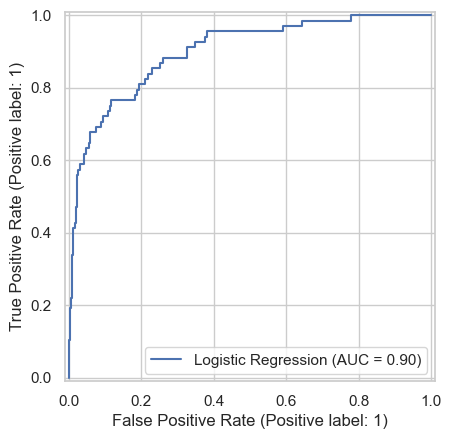

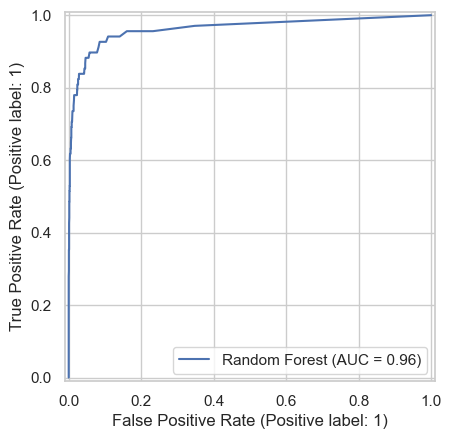

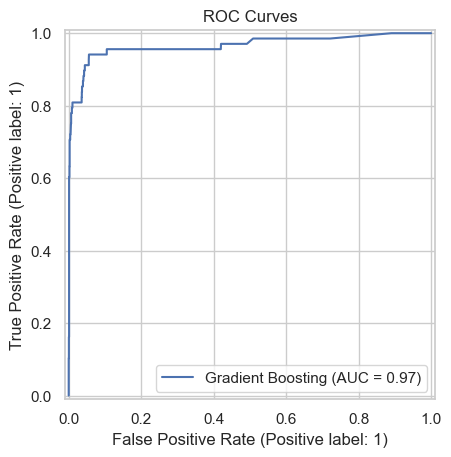

In [36]:
plt.figure(figsize=(8, 6))

for name, model in fitted_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

plt.title("ROC Curves")
plt.show()

#### Feature importance

For the Random Forest model, we can inspect which variables matter most.

Because preprocessing changes the feature representation, first obtain the transformed feature names:

In [37]:
rf_pipeline = fitted_models["Random Forest"]

feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
2,num__Rotational speed [rpm],0.302162
3,num__Torque [Nm],0.300237
4,num__Tool wear [min],0.199520
0,num__Air temperature [K],0.103964
1,num__Process temperature [K],0.074626
6,cat__Type_L,0.009457
7,cat__Type_M,0.006314
5,cat__Type_H,0.003720


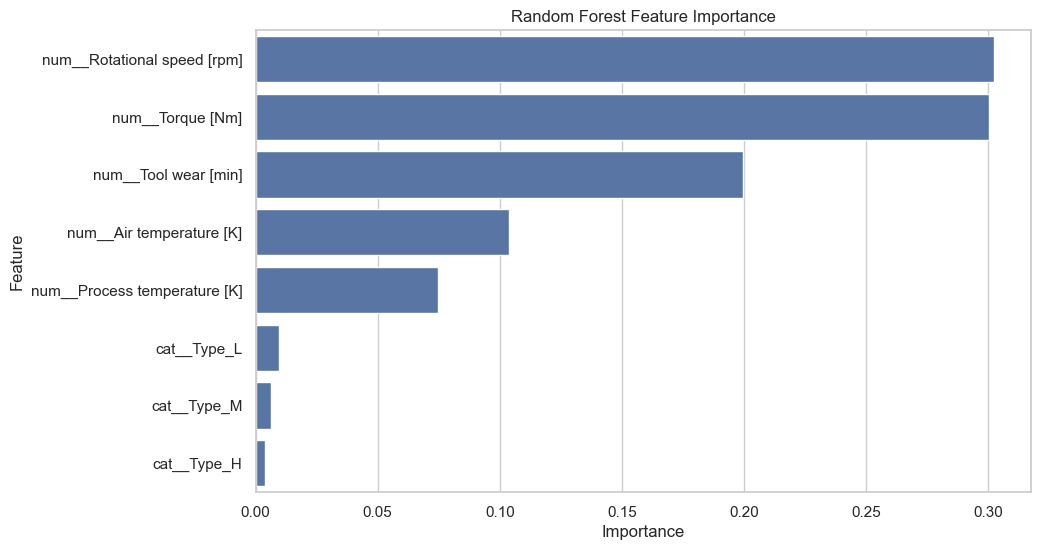

In [38]:
#Plot the feature importances

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

# Conclusion

This project developed an end-to-end machine-learning workflow for predicting machine failures using the AI4I 2020 Predictive Maintenance Dataset.

Three classification algorithms were compared: Logistic Regression, Random Forest, and Gradient Boosting. The models were evaluated using stratified 5-fold cross-validation and were subsequently tested on a held-out test set.

Because machine failure is an imbalanced classification problem, model performance was assessed using not only accuracy but also precision, recall, F1-score, and ROC-AUC. Recall was given particular consideration because false-negative predictions correspond to failures that the predictive-maintenance system fails to identify.

Based on the cross-validation and test-set results, **Gradient Boosting** provided the strongest overall performance. It achieved a cross-validation ROC-AUC of approximately **0.98** and an F1-score of approximately **0.70**, while achieving a **0.63** recall and **0.74** F1-score for the Failure class on the held-out test set. This indicates that Gradient Boosting was the most effective of the evaluated models at distinguishing between normal machine operation and machine failure.

The feature-importance analysis also provided insight into which machine operating measurements contributed most to the predictions. These results can help identify operating conditions that may be associated with increased machine-failure risk.

However, the results should be interpreted with caution. The AI4I 2020 dataset is relatively small and simulated, so performance on this dataset may not directly translate to a real industrial environment. Further work could include hyperparameter optimisation, threshold tuning to prioritise recall, additional feature engineering, and validation using real-world industrial sensor data.

Overall, the project demonstrates how a complete scikit-learn pipeline can be used to preprocess data, compare machine-learning models using cross-validation, and evaluate predictive-maintenance performance in a reproducible way.
